In [1]:
import os
import numpy as np
import tensorflow as tf
import psutil
import gc
import time
import pandas as pd
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import hashlib
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

2025-04-06 13:16:06.223745: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 13:16:06.236765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743959766.251725 2456344 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743959766.256233 2456344 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-06 13:16:06.271438: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Preprocessing

In [2]:
def load_file(path):
    data = pd.read_csv(path, sep=',', low_memory=False)
    return data

In [4]:
import pandas as pd
import os

# File paths
base_path = "/home/uottawa.o.univ/hpate033/GAN Project/CIC-DDoS2019/"
files = [
    "DrDoS_LDAP.csv", "DrDoS_MSSQL.csv", "DrDoS_NetBIOS.csv",
    "DrDoS_NTP.csv", "DrDoS_SNMP.csv", "DrDoS_SSDP.csv",
    "DrDoS_UDP.csv", "DrDoS_DNS.csv"
]

# Initialize an empty DataFrame
ddos_df = pd.DataFrame()

# Process each file
for i, file in enumerate(files, start=1):
    file_path = os.path.join(base_path, file)
    
    try:
        # Load the file
        df = pd.read_csv(file_path)
        
        # Separate benign and non-benign samples
        benign_samples = df[df[' Label'] == 'BENIGN']
        non_benign_samples = df[df[' Label'] != 'BENIGN']
        
        # Sample 500,000 non-benign samples (or all if less than 500,000)
        if len(non_benign_samples) > 500000:
            non_benign_samples = non_benign_samples.sample(n=500000, random_state=42)
        
        # Combine benign and sampled non-benign samples
        processed_df = pd.concat([benign_samples, non_benign_samples], ignore_index=True)
        
        # Append to the main DataFrame
        ddos_df = pd.concat([ddos_df, processed_df], ignore_index=True)
        
        print(f'File {i} processed')
    except FileNotFoundError:
        print(f'File {i} not found: {file_path}')
    except Exception as e:
        print(f'Error processing file {i}: {str(e)}')


/usr/lib/python3/dist-packages/IPython/core/interactiveshell.py:3457: DtypeWarning: Columns (85) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


File 1 processed
File 2 processed
File 3 processed
File 4 processed
File 5 processed
File 6 processed
File 7 processed
File 8 processed


In [5]:
import pandas as pd
import numpy as np
import hashlib

ddos_df.info()

# Function to convert string to numeric hash
def string2numeric_hash(text):
    return int(hashlib.md5(text.encode()).hexdigest()[:8], 16)

# Replace infinite values
ddos_df = ddos_df.replace(['Infinity', np.inf], 0)

# Convert numerical columns safely
ddos_df[' Flow Packets/s'] = pd.to_numeric(ddos_df[' Flow Packets/s'], errors='coerce').fillna(0)
ddos_df['Flow Bytes/s'] = pd.to_numeric(ddos_df['Flow Bytes/s'], errors='coerce').fillna(0)

# Convert labels to numeric
ddos_df[' Label'] = ddos_df[' Label'].replace({
    'BENIGN': 0, 'DrDoS_DNS': 1, 'DrDoS_LDAP': 1, 'DrDoS_MSSQL': 1,
    'DrDoS_NTP': 1, 'DrDoS_NetBIOS': 1, 'DrDoS_SNMP': 1, 'DrDoS_SSDP': 1,
    'DrDoS_UDP': 1
}).astype(int)

# Drop unnecessary columns
ddos_df.drop(columns=[' Timestamp', ' Source IP', ' Destination IP', 'Flow ID', 'SimillarHTTP', 'Unnamed: 0'], inplace=True)

# Remove space in columns
ddos_df.columns = ddos_df.columns.str.strip()

# Display information about the final dataset
print(f"Final DataFrame shape: {ddos_df.shape}")
print(f"Benign samples: {sum(ddos_df['Label'] == 0)}")
print(f"Attack samples: {sum(ddos_df['Label'] == 1)}")
print('Data processed successfully!')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4027519 entries, 0 to 4027518
Data columns (total 88 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Unnamed: 0                    int64  
 1   Flow ID                       object 
 2    Source IP                    object 
 3    Source Port                  int64  
 4    Destination IP               object 
 5    Destination Port             int64  
 6    Protocol                     int64  
 7    Timestamp                    object 
 8    Flow Duration                int64  
 9    Total Fwd Packets            int64  
 10   Total Backward Packets       int64  
 11  Total Length of Fwd Packets   float64
 12   Total Length of Bwd Packets  float64
 13   Fwd Packet Length Max        float64
 14   Fwd Packet Length Min        float64
 15   Fwd Packet Length Mean       float64
 16   Fwd Packet Length Std        float64
 17  Bwd Packet Length Max         float64
 18   Bwd Packet Length Min

In [6]:
print(ddos_df.shape)

ddos_df.info()

print(ddos_df.columns)

(4027519, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4027519 entries, 0 to 4027518
Data columns (total 82 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  int64  
 1   Destination Port             int64  
 2   Protocol                     int64  
 3   Flow Duration                int64  
 4   Total Fwd Packets            int64  
 5   Total Backward Packets       int64  
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean               

In [7]:
# Step 1. Load and preprocess the dataset.

# Print the available columns to double-check the header.
print("Dataset columns:\n", ddos_df.columns.tolist())

# Check if the 'Label' column exists.
if 'Label' not in ddos_df.columns:
    raise KeyError("Column 'Label' not found in the dataset. Please verify the CSV header.")

# Filter the dataset to include only attack samples (assume attack samples have Label == 1)
attack_data = ddos_df[ddos_df['Label'] == 1]
benign_data = ddos_df[ddos_df['Label'] == 0]

# Split your data
attack_data_train, attack_data_test = train_test_split(attack_data, test_size=0.3, random_state=42)
benign_data_train, benign_data_test = train_test_split(benign_data, test_size=0.3, random_state=42)

ddos_df_train = pd.concat([attack_data_train, benign_data_train], ignore_index=True)
ddos_df_test = pd.concat([attack_data_test, benign_data_test], ignore_index=True)

Dataset columns:
 ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG F

In [8]:
del attack_data, benign_data

In [9]:
# Separate features (drop the Label column)
X = attack_data_train.drop(columns=['Label'])
feature_names = X.columns  # Save feature names for later interpretation
X = X.values

# Normalize features to the [0, 1] range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
del X
num_samples, num_features = X_scaled.shape
print(f"Loaded {num_samples} attack samples with {num_features} features.")

Loaded 2800000 attack samples with 81 features.


In [10]:
print(feature_names)

Index(['Source Port', 'Destination Port', 'Protocol', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag 

# GANFS Algorithm

In [11]:
# Step 0. Check for GPU and configure memory growth.
gpus = tf.config.list_physical_devices('GPU')
print(gpus)
if gpus:
    try:
        for gpu in gpus:
            # Enable memory growth so that TensorFlow does not allocate all GPU memory
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU detected and memory growth enabled.")
    except RuntimeError as e:
        print("Error setting memory growth: ", e)
else:
    print("No GPU detected; running on CPU.")

device = '/GPU:0' if gpus else '/CPU:0'
print(device)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected and memory growth enabled.
/GPU:0


In [12]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
# Step 2. Build the GAN models.
def build_generator(input_dim, output_dim):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(output_dim, activation='sigmoid')
    ])
    return model

def build_discriminator(input_dim):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_dim=input_dim),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

with tf.device(device):
    # Build generator and discriminator
    generator = build_generator(num_features, num_features)
    discriminator = build_discriminator(num_features)

    # Compile the discriminator
    discriminator.compile(loss='binary_crossentropy',
                          optimizer=optimizers.Adam(learning_rate=0.001),
                          metrics=['accuracy'])

    # Create the GAN model
    discriminator.trainable = True
    gan_input = layers.Input(shape=(num_features,))
    generated_sample = generator(gan_input)
    gan_output = discriminator(generated_sample)
    gan = models.Model(gan_input, gan_output)
    gan.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(learning_rate=0.001))

print("Generator, Discriminator, and GAN models are built and compiled.")

I0000 00:00:1743959955.108864 2456344 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8085 MB memory:  -> device: 0, name: NVIDIA H100 PCIe MIG 1g.10gb, pci bus id: 0000:65:00.0, compute capability: 9.0
/usr/lib/python3/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Generator, Discriminator, and GAN models are built and compiled.


In [14]:
discriminator.compile(loss='binary_crossentropy',
                          optimizer=optimizers.Adam(learning_rate=0.001),
                          metrics=['accuracy'])

In [15]:
print(discriminator.optimizer)  # Should print the optimizer details
print(discriminator.loss)  # Should print the loss function
print(discriminator.metrics)  # Should print the metrics

binary_crossentropy
[<Mean name=loss>, <CompileMetrics name=compile_metrics>]


In [16]:
# Ensure the checkpoint directory exists
checkpoint_dir = './training_checkpoints'
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

# Assume these objects are created elsewhere in your code:
# generator, discriminator, gan, gen_optimizer, disc_optimizer

# Create a checkpoint instance that tracks models and optimizer states
checkpoint = tf.train.Checkpoint(generator=generator,
                                 discriminator=discriminator,
                                 gan=gan)

# Define training parameters
epochs = 500
batch_size = 4096

with tf.device(device):
    print("Starting GAN training on", device)
    for epoch in range(epochs):
        # ---------------------
        # Train the discriminator
        # ---------------------
        # Get the total number of samples and select a random batch
        num_samples = X_scaled.shape[0]
        idx = np.random.choice(num_samples, batch_size, replace=False)
        real_samples = X_scaled[idx]

        # Generate a synthetic batch from noise
        noise = np.random.normal(0, 1, (batch_size, num_features))
        fake_samples = generator.predict(noise, verbose=0)

        # Use label smoothing for more stable training
        real_labels = 0.9 * np.ones((batch_size, 1))
        fake_labels = 0.1 * np.ones((batch_size, 1))

        # Train on real and fake samples
        d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # ---------------------
        # Train the generator
        # ---------------------
        noise = np.random.normal(0, 1, (batch_size, num_features))
        valid_y = np.ones((batch_size, 1))  # Generator aims for discriminator to output 1
        g_loss = gan.train_on_batch(noise, valid_y)

        # Every 20 epochs, display progress and save a checkpoint
        if epoch % 20 == 0:
            # If the discriminator loss returns both loss and accuracy info (e.g. [loss, acc]),
            # extract them; otherwise, use defaults.
            d_loss_value = d_loss[0] if isinstance(d_loss, (list, np.ndarray)) else d_loss
            d_acc = d_loss[1] if isinstance(d_loss, (list, np.ndarray)) and len(d_loss) > 1 else 0.0

            # Print formatted outputs with zero-padded epoch and formatted loss/accuracy.
            print(f"Epoch {epoch:04d}: D_loss = {d_loss_value:.4f} (acc: {100*d_acc:05.2f}%), G_loss = {g_loss:.4f}")
            # Save the current training state
            checkpoint.save(file_prefix=checkpoint_prefix)

    print("GAN training finished.")


Starting GAN training on /GPU:0


I0000 00:00:1743959956.023130 2459336 service.cc:148] XLA service 0x1462b80175f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743959956.023168 2459336 service.cc:156]   StreamExecutor device (0): NVIDIA H100 PCIe MIG 1g.10gb, Compute Capability 9.0
2025-04-06 13:19:16.027425: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1743959956.048185 2459336 cuda_dnn.cc:529] Loaded cuDNN version 90501
I0000 00:00:1743959960.954230 2459336 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-04-06 13:19:24.008661: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_164', 100 bytes spill stores, 88 bytes spill loads

2025-04-06 13:19:24.474458: I externa

Epoch 0000: D_loss = 0.7163 (acc: 00.00%), G_loss = 1.1838


Epoch 0020: D_loss = 0.4913 (acc: 00.00%), G_loss = 1.0717
Epoch 0040: D_loss = 0.4648 (acc: 00.00%), G_loss = 1.0944
Epoch 0060: D_loss = 0.4423 (acc: 00.00%), G_loss = 1.1571
Epoch 0080: D_loss = 0.4293 (acc: 00.00%), G_loss = 1.1961
Epoch 0100: D_loss = 0.4238 (acc: 00.00%), G_loss = 1.2074
Epoch 0120: D_loss = 0.4155 (acc: 00.00%), G_loss = 1.2424
Epoch 0140: D_loss = 0.4165 (acc: 00.00%), G_loss = 1.2505
Epoch 0160: D_loss = 0.4140 (acc: 00.00%), G_loss = 1.2734
Epoch 0180: D_loss = 0.4123 (acc: 00.00%), G_loss = 1.2866
Epoch 0200: D_loss = 0.4112 (acc: 00.00%), G_loss = 1.3001
Epoch 0220: D_loss = 0.4067 (acc: 00.00%), G_loss = 1.3355
Epoch 0240: D_loss = 0.4029 (acc: 00.00%), G_loss = 1.3683
Epoch 0260: D_loss = 0.3991 (acc: 00.00%), G_loss = 1.4116
Epoch 0280: D_loss = 0.3953 (acc: 00.00%), G_loss = 1.4538
Epoch 0300: D_loss = 0.3920 (acc: 00.00%), G_loss = 1.4921
Epoch 0320: D_loss = 0.3888 (acc: 00.00%), G_loss = 1.5248
Epoch 0340: D_loss = 0.3862 (acc: 00.00%), G_loss = 1.55

# Calculating predictions and sensitivity

In [17]:
def compute_baseline_predictions(model, data, safety_factor=0.7):
    """Memory-optimized prediction generator using direct batch generation."""
    print("🚀 Initializing memory-safe prediction pipeline...")
    print(f"• Input shape: {data.shape}")
    print(f"• Initial RAM: {psutil.virtual_memory().available/1e9:.2f} GB\n")

    # Convert to float16 if possible to reduce memory footprint
    if model.dtype == tf.float16:
        data = data.astype(np.float16)
        print("• Using float16 precision")
    else:
        data = data.astype(np.float32)
        print("• Using float32 precision")

    def calculate_batch_size():
        bytes_per_sample = data.shape[1] * (2 if data.dtype == np.float16 else 4)
        available_mem = psutil.virtual_memory().available * safety_factor
        max_batch = int(available_mem / (bytes_per_sample * 3))
        return max(512, min(max_batch, 4194304))

    # Configure TensorFlow for optimal large dataset handling
    tf.config.optimizer.set_jit(True)

    optimal_batch_size = calculate_batch_size()
    print(f"\n⚙️ Initial batch size: {optimal_batch_size}")
    
    def data_generator():
        for i in range(0, len(data), optimal_batch_size):
            yield data[i:i+optimal_batch_size]

    baseline_preds = None
    retry_count = 0
    start_time = time.time()

    print(f"\n⚙️ Initial batch size: {optimal_batch_size}")
    print("──────────────────────────────────────────────────")

    while True:
        try:
            # Create dataset from generator with proper typing
            dataset = tf.data.Dataset.from_generator(
                data_generator,
                output_signature=tf.TensorSpec(shape=(None, data.shape[1]), dtype=data.dtype)
            ).prefetch(tf.data.AUTOTUNE)

            total_batches = np.ceil(len(data) / optimal_batch_size).astype(int)
            
            if baseline_preds is None:
                print("\n🔨 Allocating prediction array...")
                sample_pred = model(data[:1]).numpy()
                baseline_preds = np.empty((len(data), *sample_pred.shape[1:]), 
                                       dtype=sample_pred.dtype)
                print(f"• Prediction array size: {baseline_preds.nbytes/1e9:.2f} GB")
                print("──────────────────────────────────────────────────")

            print(f"\n🔍 Starting batch processing (attempt {retry_count+1})...")
            current_idx = 0
            for batch_idx, batch in enumerate(dataset):
                pred = model(batch, training=False).numpy()
                batch_size = pred.shape[0]
                baseline_preds[current_idx:current_idx + batch_size] = pred
                current_idx += batch_size

                # Memory management
                del pred, batch
                if batch_idx % 10 == 0:
                    tf.keras.backend.clear_session()
                    gc.collect()

                # Progress reporting
                if batch_idx % 100 == 0 or batch_idx == total_batches-1:
                    elapsed = time.time() - start_time
                    mem = psutil.virtual_memory()
                    progress = current_idx/len(data)*100
                    print(
                        f"\r▏{'█' * int(progress/2)}{' ' * (50 - int(progress/2))}▏ "
                        f"{progress:.1f}% • "
                        f"Batch {batch_idx+1}/{total_batches} • "
                        f"RAM: {mem.used/1e9:.1f}/{mem.total/1e9:.1f} GB • "
                        f"Elapsed: {elapsed//60:.0f}m {elapsed%60:.0f}s",
                        end="", flush=True
                    )

            break

        except tf.errors.ResourceExhaustedError:
            retry_count += 1
            print(f"\n\n⚠️ Memory overload at batch size {optimal_batch_size}!")
            optimal_batch_size = max(optimal_batch_size // 2, 128)
            print(f"🔄 Retrying with batch size: {optimal_batch_size}")
            print("──────────────────────────────────────────────────")

    # Finalization
    total_time = time.time() - start_time
    
    print(f"\n\n🎉 Successfully processed {len(data):,} samples!")
    print(f"• Final batch size: {optimal_batch_size}")
    print(f"• Total duration: {total_time//60:.0f}m {total_time%60:.0f}s")
    print(f"• Peak RAM usage: {psutil.virtual_memory().percent}%")
    print("──────────────────────────────────────────────────")

    return baseline_preds, optimal_batch_size


In [18]:
# Generate baseline predictions
baseline_preds, batch_size = compute_baseline_predictions(
    model=discriminator,
    data=X_scaled,
    safety_factor=0.7  # Adjust based on your system
)

🚀 Initializing memory-safe prediction pipeline...
• Input shape: (2800000, 81)
• Initial RAM: 486.40 GB

• Using float32 precision

⚙️ Initial batch size: 4194304

⚙️ Initial batch size: 4194304
──────────────────────────────────────────────────

🔨 Allocating prediction array...
• Prediction array size: 0.01 GB
──────────────────────────────────────────────────

🔍 Starting batch processing (attempt 1)...
▏██████████████████████████████████████████████████▏ 100.0% • Batch 1/1 • RAM: 52.3/540.5 GB • Elapsed: 0m 3s

🎉 Successfully processed 2,800,000 samples!
• Final batch size: 4194304
• Total duration: 0m 3s
• Peak RAM usage: 10.4%
──────────────────────────────────────────────────


2025-04-06 13:26:04.975371: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
batch_size = 2097152

In [20]:
def improved_sensitivity_analysis(model, data, baseline_preds, batch_size,
                                 perturbation_mode='dynamic',
                                 perturbation_factors=[0.5, 1.0, 2.0, 5.0],
                                 safety_factor=0.6):
    """Sensitivity analysis with neighbor-based dynamic perturbations"""
    n_samples, n_features = data.shape
    sensitivities = np.zeros(n_features, dtype=np.float32)
    start_time = time.time()

    # Precompute neighbor differences for dynamic mode
    if perturbation_mode == 'dynamic':
        def calculate_feature_granularity(feature_data):
            sorted_values = np.sort(feature_data)
            diffs = np.diff(sorted_values)
            non_zero_diffs = diffs[diffs > 0]
            if len(non_zero_diffs) == 0:
                return max(1e-3, 0.01 * (np.max(feature_data) - np.min(feature_data)))
            return np.mean(non_zero_diffs)
        
        base_deltas = np.array([calculate_feature_granularity(data[:, i]) 
                              for i in range(n_features)])
        print(base_deltas)
        print("🔍 Computed feature granularity based on neighbor differences")
    else:
        print("⚖️ Using static perturbation levels")

    total_operations = n_features * len(perturbation_factors) * 2
    print(f"\n🚀 Launching sensitivity analysis with:")
    print(f"• Features: {n_features} | Perturbations: {len(perturbation_factors)}")
    print(f"• Total operations: {total_operations:,}")
    print(f"• Batch size: {batch_size:,} samples")
    print(f"• Perturbation mode: {perturbation_mode.upper()}")
    print("──────────────────────────────────────────────────")

    for feat_idx in range(n_features):
        feature_start = time.time()
        progress_bar = f"[{'▋'*(20*(feat_idx+1)//n_features)}{' '*(20-20*(feat_idx+1)//n_features)}]"
        print(f"\n🔧 Feature {feat_idx+1}/{n_features} {progress_bar}")
        print(f"• Current RAM: {psutil.virtual_memory().percent}% used")
        print(f"• Elapsed: {time.time()-start_time:.1f}s")
        
        # Determine perturbation magnitudes
        if perturbation_mode == 'dynamic':
            base_Δ = base_deltas[feat_idx]
            deltas = [f * base_Δ for f in perturbation_factors]
            delta_info = f"(base Δ={base_Δ:.4f} → deltas: {[f'{d:.4f}' for d in deltas]})"
        else:
            deltas = perturbation_factors
            delta_info = f"(static deltas: {perturbation_factors})"
            
        print(f"• Perturbation strategy: {delta_info}")
        feature_sens = 0.0

        for delta_idx, delta in enumerate(deltas):
            delta_start = time.time()
            delta_sens = 0.0
            print(f"\n  🎚️ Perturbation {delta_idx+1}/{len(deltas)} (δ={delta:.4f})")
            
            for direction in [1, -1]:
                dir_start = time.time()
                total_diff = 0.0
                batches_processed = 0
                print(f"  ↕️ Direction: {'+' if direction >0 else '-'}")
                
                for start in range(0, n_samples, batch_size):
                    batch_data = data[start:start+batch_size].copy()
                    original_values = batch_data[:, feat_idx]
                    
                    # Apply smart perturbation with neighbor awareness
                    perturbed = original_values + direction * delta
                    batch_data[:, feat_idx] = np.clip(
                        np.where(
                            (perturbed >= np.min(original_values)) & 
                            (perturbed <= np.max(original_values)),
                            perturbed,
                            original_values  # Preserve original if beyond natural range
                        ), 0, 1
                    )
                    
                    perturbed_preds = model(batch_data).numpy()
                    total_diff += np.abs(perturbed_preds - baseline_preds[start:start+batch_size]).sum()
                    batches_processed += 1

                    # Memory optimization
                    if batches_processed % 10 == 0:
                        gc.collect()
                        tf.keras.backend.clear_session()

                mean_diff = total_diff / n_samples
                delta_sens += mean_diff
                print(f"\n  ✓ Direction complete: {time.time()-dir_start:.1f}s | Δ={mean_diff:.4f}")

            # Update sensitivity
            feature_sens += delta_sens / 2  # Average directions
            print(f"  🕒 Perturbation time: {time.time()-delta_start:.1f}s")
        
        sensitivities[feat_idx] = feature_sens / len(deltas)
        print(f"\n📊 Feature {feat_idx+1} complete: {sensitivities[feat_idx]:.4f}")
        print(f"⏱️ Feature time: {time.time()-feature_start:.1f}s")
        print(f"🔮 Estimated remaining: {(time.time()-start_time)*(n_features-feat_idx-1)/(feat_idx+1):.1f}s")
        print("──────────────────────────────────────────────────")
    
    total_time = time.time() - start_time
    print(f"\n✅ Analysis completed in {total_time//3600:.0f}h {total_time%3600//60:.0f}m {total_time%60:.0f}s!")
    print(f"• Peak RAM usage: {psutil.virtual_memory().percent}%")
    return sensitivities


# Run the improved sensitivity analysis
print("\nPerforming improved feature sensitivity analysis...")
sensitivities = improved_sensitivity_analysis(discriminator, X_scaled, baseline_preds, batch_size,
                                              perturbation_factors=[0.5, 1.0, 2.0, 5.0, 10])

# Display individual feature sensitivity scores
print("\nFeature Sensitivity Scores:")
for feature, sens in zip(feature_names, sensitivities):
    print(f"Feature: {feature}, Sensitivity: {sens:.4f}")




Performing improved feature sensitivity analysis...
[1.64655130e-05 1.52597204e-05 5.00000000e-01 1.36098862e-05
 3.81679389e-03 2.38095238e-02 3.93545848e-04 2.08333333e-02
 7.38007380e-04 7.38552437e-04 4.16840350e-04 7.04721635e-04
 7.69230769e-02 3.33333333e-01 1.25000000e-02 1.29870130e-02
 3.88902284e-06 5.75798056e-06 4.18985051e-06 2.04336428e-06
 2.68053396e-05 3.01204819e-03 1.36354959e-05 4.19320617e-06
 2.04460929e-06 2.68809978e-05 3.21543408e-03 1.77935943e-03
 1.75438596e-03 1.81818182e-03 1.96850394e-03 4.76190476e-02
 1.00000000e+00 1.00000000e-03 1.00000000e-03 1.00000000e-03
 1.94855807e-04 1.63934426e-02 5.79240037e-06 9.68054211e-04
 7.38552437e-04 7.40192450e-04 3.68731563e-04 6.68002672e-04
 5.97014925e-04 1.00000000e-03 1.00000000e+00 1.00000000e+00
 1.00000000e-03 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e-03 2.00000000e-01 3.14762354e-04 4.48631673e-04
 1.29870130e-02 1.94855807e-04 1.00000000e-03 1.00000000e-03
 1.00000000e-03 1.00000000e-03 1

In [21]:
# Rank features by sensitivity
sorted_idx = np.argsort(-sensitivities)
print("\nRanking of Features by Sensitivity:")
for i, idx in enumerate(sorted_idx): 
    print(f"{i+1}. {feature_names[idx]}: {sensitivities[idx]}")


Ranking of Features by Sensitivity:
1. URG Flag Count: 0.02257869392633438
2. Protocol: 0.016681384295225143
3. Inbound: 0.015444500371813774
4. Bwd Packet Length Max: 0.010720941238105297
5. Down/Up Ratio: 0.005439216736704111
6. Idle Std: 0.005243473686277866
7. RST Flag Count: 0.003362539689987898
8. Fwd PSH Flags: 0.0031485194340348244
9. Bwd IAT Min: 0.002834815764799714
10. Active Mean: 0.0023478514049202204
11. SYN Flag Count: 0.002086169319227338
12. Total Backward Packets: 0.0016662804409861565
13. CWE Flag Count: 0.001646710792556405
14. act_data_pkt_fwd: 0.0014287886442616582
15. Bwd Packet Length Min: 0.0013595283962786198
16. Init_Win_bytes_backward: 0.0013470668345689774
17. Init_Win_bytes_forward: 0.001196552999317646
18. ACK Flag Count: 0.0011681000469252467
19. Bwd Packet Length Mean: 0.0011323656653985381
20. Active Std: 0.001072747283615172
21. Active Max: 0.0010572021128609776
22. Subflow Bwd Bytes: 0.0008834468899294734
23. Avg Bwd Segment Size: 0.0007682931027375

In [22]:
# Save results to file
results_df = pd.DataFrame({
    'Feature': feature_names,
    'Sensitivity_Score': sensitivities
}).sort_values('Sensitivity_Score', ascending=False)

results_df.to_csv('feature_sensitivity_results.csv', index=False)
print("\nResults saved to 'feature_sensitivity_results.csv'")


Results saved to 'feature_sensitivity_results.csv'


In [23]:
# Create a list of sorted feature names
sorted_feature_names = [feature_names[idx] for idx in sorted_idx]
print("\nList of features sorted by sensitivity:")
print(sorted_feature_names)

# If you also want feature names with their sensitivity values
sorted_features_with_values = [(feature_names[idx], sensitivities[idx]) for idx in sorted_idx]


List of features sorted by sensitivity:
['URG Flag Count', 'Protocol', 'Inbound', 'Bwd Packet Length Max', 'Down/Up Ratio', 'Idle Std', 'RST Flag Count', 'Fwd PSH Flags', 'Bwd IAT Min', 'Active Mean', 'SYN Flag Count', 'Total Backward Packets', 'CWE Flag Count', 'act_data_pkt_fwd', 'Bwd Packet Length Min', 'Init_Win_bytes_backward', 'Init_Win_bytes_forward', 'ACK Flag Count', 'Bwd Packet Length Mean', 'Active Std', 'Active Max', 'Subflow Bwd Bytes', 'Avg Bwd Segment Size', 'Active Min', 'Subflow Bwd Packets', 'Total Length of Bwd Packets', 'Bwd Packet Length Std', 'Fwd Packet Length Min', 'Bwd Header Length', 'Average Packet Size', 'Max Packet Length', 'Fwd IAT Min', 'Fwd Packet Length Std', 'Fwd Packet Length Mean', 'Bwd IAT Total', 'min_seg_size_forward', 'Bwd IAT Std', 'Total Length of Fwd Packets', 'Bwd IAT Max', 'Subflow Fwd Bytes', 'Fwd Packet Length Max', 'Idle Max', 'Subflow Fwd Packets', 'Packet Length Variance', 'Idle Mean', 'Avg Fwd Segment Size', 'Total Fwd Packets', 'Bwd 

In [24]:
import itertools 
# Step 5. Feature Combination Analysis
def feature_pair_sensitivity(model, data, baseline_preds, individual_sensitivities, batch_size, top_n,  delta=0.1, safety_factor=0.5):
    """Mission-critical interaction analysis with intelligent memory handling"""
    n_samples, _ = data.shape
    data = data.astype(np.float32)
    pair_results = []
    start_time = time.time()
    top_indices = np.argsort(-individual_sensitivities)[:top_n]
    total_pairs = len(list(itertools.combinations(top_indices, 2)))
    
    batches_per_pair = (n_samples + batch_size - 1) // batch_size
    
    print(f"\n🚀 Launching pair analysis with:")
    print(f"• Total pairs: {total_pairs}")
    print(f"• Samples per pair: {n_samples:,}")
    print(f"• Batches per pair: {batches_per_pair}")
    print(f"• Estimated total batches: {total_pairs * batches_per_pair:,}")
    print("──────────────────────────────────────────────────")

    for pair_idx, (i, j) in enumerate(itertools.combinations(top_indices, 2)):
        pair_start = time.time()
        feat1, feat2 = feature_names[i], feature_names[j]
        total_diff = 0.0
        
        # Pair header with progress tracking
        print(f"\n🔗 Pair {pair_idx+1}/{total_pairs} [{'▋'*(20*(pair_idx+1)//total_pairs)}{' '*(20-20*(pair_idx+1)//total_pairs)}]")
        print(f"• Features: {feat1} & {feat2}")
        print(f"• Elapsed: {time.time()-start_time:.1f}s")
        print(f"• Current RAM: {psutil.virtual_memory().percent}%")
        print("──────────────────────────────────────────────────")

        for batch_idx in range(0, n_samples, batch_size):
            batch_start = time.time()
            end = min(batch_idx + batch_size, n_samples)
            batch_data = data[batch_idx:end].copy()
            
            # Apply dual perturbation
            batch_data[:, [i, j]] = np.clip(batch_data[:, [i, j]] + delta, 0, 1)
            
            # Compute impact
            perturbed_preds = model(batch_data).numpy()
            total_diff += np.abs(perturbed_preds - baseline_preds[batch_idx:end]).sum()
            
            # Progress tracking every 5% of batches or 10 batches minimum
            current_batch = (batch_idx // batch_size) + 1
            if current_batch % max(10, batches_per_pair//20) == 0 or current_batch == batches_per_pair:
                elapsed = time.time() - pair_start
                progress = (current_batch/batches_per_pair)*100
                mem = psutil.virtual_memory()
                print(
                    f"\r▏{'█' * int(progress//5)}{' ' * (20 - int(progress//5))}▏ "
                    f"{progress:.1f}% | "
                    f"Batch {current_batch}/{batches_per_pair} | "
                    f"RAM: {mem.percent}% | "
                    f"Time: {elapsed:.1f}s", end="", flush=True
                )
            
            # Memory maintenance every 10 batches
            if current_batch % 10 == 0:
                gc.collect()
                tf.keras.backend.clear_session()
                print(f"\n♻️ Memory cleaned | RAM: {psutil.virtual_memory().percent}%")

        # Calculate metrics
        combined_sens = total_diff / n_samples
        interaction = combined_sens - (individual_sensitivities[i] + individual_sensitivities[j])
        
        pair_results.append({
            'features': (feat1, feat2),
            'combined_impact': combined_sens,
            'synergy_score': interaction,
            'individual_sum': individual_sensitivities[i] + individual_sensitivities[j]
        })
        
        # Pair summary
        pair_time = time.time() - pair_start
        print(f"\n\n✅ Pair complete:")
        print(f"  ⚡ Combined impact: {combined_sens:.4f}")
        print(f"  💥 Synergy score: {interaction:.4f}")
        print(f"  ⏱️ Processing time: {pair_time:.1f}s")
        print(f"  🔮 Estimated remaining: {(time.time()-start_time)*(total_pairs-pair_idx-1)/(pair_idx+1):.1f}s")
        print("──────────────────────────────────────────────────")

    # Final summary
    total_time = time.time() - start_time
    print(f"\n🎉 Analysis completed in {total_time//3600:.0f}h {total_time%3600//60:.0f}m {total_time%60:.0f}s!")
    print(f"• Total pairs processed: {total_pairs}")
    print(f"• Peak RAM usage: {psutil.virtual_memory().percent}%")
    print(f"• Final batch size: {batch_size}")
    
    return sorted(pair_results, key=lambda x: x['synergy_score'], reverse=True)


# Analyze feature combinations
print("\nAnalyzing feature pair interactions...")
pair_results = feature_pair_sensitivity(discriminator, X_scaled, baseline_preds, sensitivities, batch_size, top_n=20)



Analyzing feature pair interactions...

🚀 Launching pair analysis with:
• Total pairs: 190
• Samples per pair: 2,800,000
• Batches per pair: 2
• Estimated total batches: 380
──────────────────────────────────────────────────

🔗 Pair 1/190 [                    ]
• Features: URG Flag Count & Protocol
• Elapsed: 0.0s
• Current RAM: 10.9%
──────────────────────────────────────────────────
▏████████████████████▏ 100.0% | Batch 2/2 | RAM: 10.9% | Time: 1.0s

✅ Pair complete:
  ⚡ Combined impact: 0.0099
  💥 Synergy score: -0.0294
  ⏱️ Processing time: 1.0s
  🔮 Estimated remaining: 193.2s
──────────────────────────────────────────────────

🔗 Pair 2/190 [                    ]
• Features: URG Flag Count & Inbound
• Elapsed: 1.0s
• Current RAM: 10.9%
──────────────────────────────────────────────────
▏████████████████████▏ 100.0% | Batch 2/2 | RAM: 10.9% | Time: 1.0s

✅ Pair complete:
  ⚡ Combined impact: 0.0099
  💥 Synergy score: -0.0282
  ⏱️ Processing time: 1.0s
  🔮 Estimated remaining: 187.8

In [25]:
print("\nTop Feature Pairs with Synergistic Effects:")
for i, pair in enumerate(pair_results): # Show top 10 pairs if pair_results already holds the top pairs
    feat1, feat2 = pair['features']
    print(f"{i+1}. {feat1} + {feat2}: Combined Impact={pair['combined_impact']:.4f}, Synergy Score={pair['synergy_score']:.4f}, Individual Sum={pair['individual_sum']:.4f}")


Top Feature Pairs with Synergistic Effects:
1. Active Mean + act_data_pkt_fwd: Combined Impact=0.0245, Synergy Score=0.0207, Individual Sum=0.0038
2. act_data_pkt_fwd + Bwd Packet Length Mean: Combined Impact=0.0220, Synergy Score=0.0195, Individual Sum=0.0026
3. Bwd IAT Min + act_data_pkt_fwd: Combined Impact=0.0222, Synergy Score=0.0180, Individual Sum=0.0043
4. Total Backward Packets + act_data_pkt_fwd: Combined Impact=0.0206, Synergy Score=0.0175, Individual Sum=0.0031
5. act_data_pkt_fwd + Init_Win_bytes_forward: Combined Impact=0.0198, Synergy Score=0.0171, Individual Sum=0.0026
6. Idle Std + act_data_pkt_fwd: Combined Impact=0.0217, Synergy Score=0.0151, Individual Sum=0.0067
7. act_data_pkt_fwd + Active Std: Combined Impact=0.0171, Synergy Score=0.0146, Individual Sum=0.0025
8. SYN Flag Count + act_data_pkt_fwd: Combined Impact=0.0175, Synergy Score=0.0140, Individual Sum=0.0035
9. act_data_pkt_fwd + ACK Flag Count: Combined Impact=0.0162, Synergy Score=0.0136, Individual Sum=

In [26]:
# Convert results to a DataFrame
results_df = pd.DataFrame({
    'Feature 1': [pair['features'][0] for pair in pair_results],
    'Feature 2': [pair['features'][1] for pair in pair_results],
    'Combined Impact': [pair['combined_impact'] for pair in pair_results],
    'Synergy Score': [pair['synergy_score'] for pair in pair_results],
    'Individual Sum': [pair['individual_sum'] for pair in pair_results]
}).sort_values('Synergy Score', ascending=False)

# Save results to CSV
results_df.to_csv('feature_pair_interactions.csv', index=False)
print("\nResults saved to 'feature_pair_interactions.csv'")


Results saved to 'feature_pair_interactions.csv'


In [27]:
print(sorted_idx)

[50  2 80 12 53 77 47 32 31 72 46  5 51 70 13 69 68 49 14 73 74 67 56 75
 66  7 15  9 37 54 41 26 11 10 27 71 29  6 30 65  8 78 64 44 76 55  4 39
 79 40 21 28 43 42 57 36 20  1 25  0  3 22 23 16 18 38 17 24 19 35 63 62
 61 60 58 59 48 52 45 33 34]


## Benchmarking

Starting DDoS detection feature selection experiment...
Training set: 2819263 samples, Test set: 1208256 samples
Captured 81 training original feature names.
Captured 81 testing original feature names.
Standardizing features...
Feature standardization complete
Defining top features based on sensitivity ranking from GANFS Algorithm...
Sensitivity-ranked features: 81 features
First 5 features: ['URG Flag Count', 'Protocol', 'Inbound', 'Bwd Packet Length Max', 'Down/Up Ratio']
Last 5 features: ['PSH Flag Count', 'ECE Flag Count', 'FIN Flag Count', 'Bwd PSH Flags', 'Fwd URG Flags']
Creating GAN feature set...
GAN feature set created with 81 features
Initializing machine learning models...
Initialized 2 models: Logistic Regression, Random Forest
Applying Chi-Square feature selection with 71 features...
Applying ANOVA feature selection with 71 features...


/usr/lib/python3/dist-packages/sklearn/feature_selection/_univariate_selection.py:114: UserWarning: Features [33 34 35 45 48 52 58 59 60 61 62 63] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx,
/usr/lib/python3/dist-packages/sklearn/feature_selection/_univariate_selection.py:116: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Applying Mutual Information feature selection with 71 features...
Feature selection outputs stored for Chi-Square, ANOVA, and Mutual Information.
Starting evaluation with feature counts: [5, 10, 20, 30, 40, 50, 60, 70]

Processing with 5 features...
  Using top 5 features from Chi-Square...
    Training Logistic Regression...
    Logistic Regression training completed in 1.8055 seconds
    Logistic Regression evaluation complete
    Training Random Forest...
    Random Forest training completed in 14.4646 seconds
    Random Forest evaluation complete
  Using top 5 features from ANOVA...
    Training Logistic Regression...
    Logistic Regression training completed in 1.7796 seconds
    Logistic Regression evaluation complete
    Training Random Forest...
    Random Forest training completed in 14.4330 seconds
    Random Forest evaluation complete
  Using top 5 features from Mutual Information...
    Training Logistic Regression...
    Logistic Regression training completed in 7.8747 se

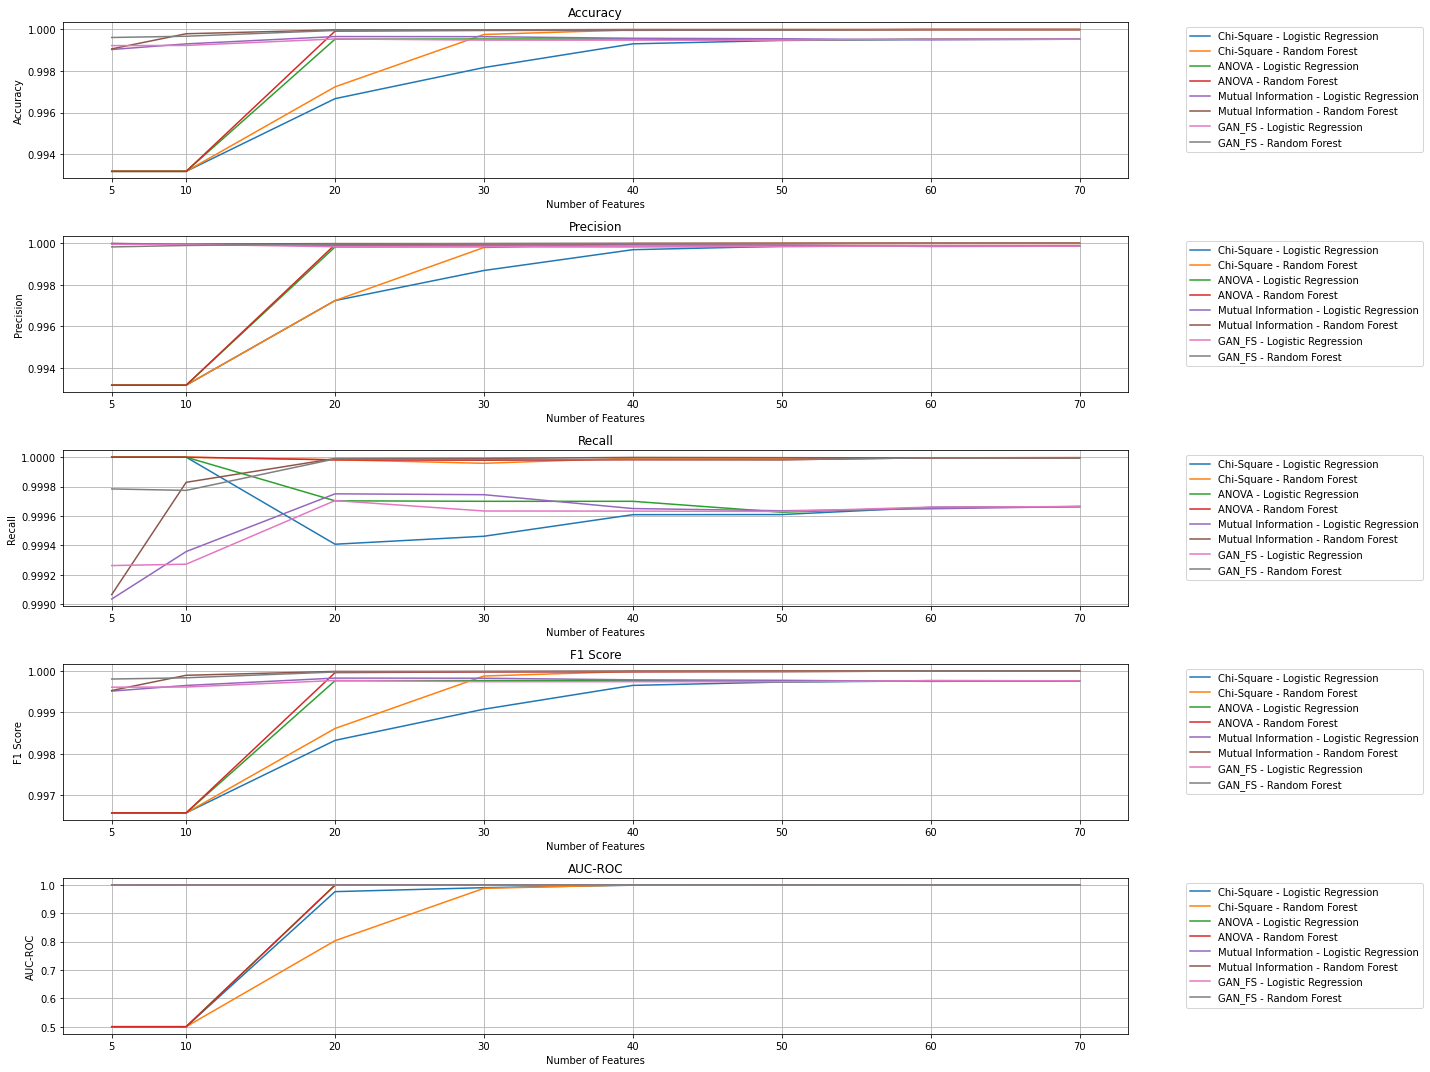

Creating individual model performance plots...
  Generating plot for Logistic Regression...
  Displaying plot for Logistic Regression...


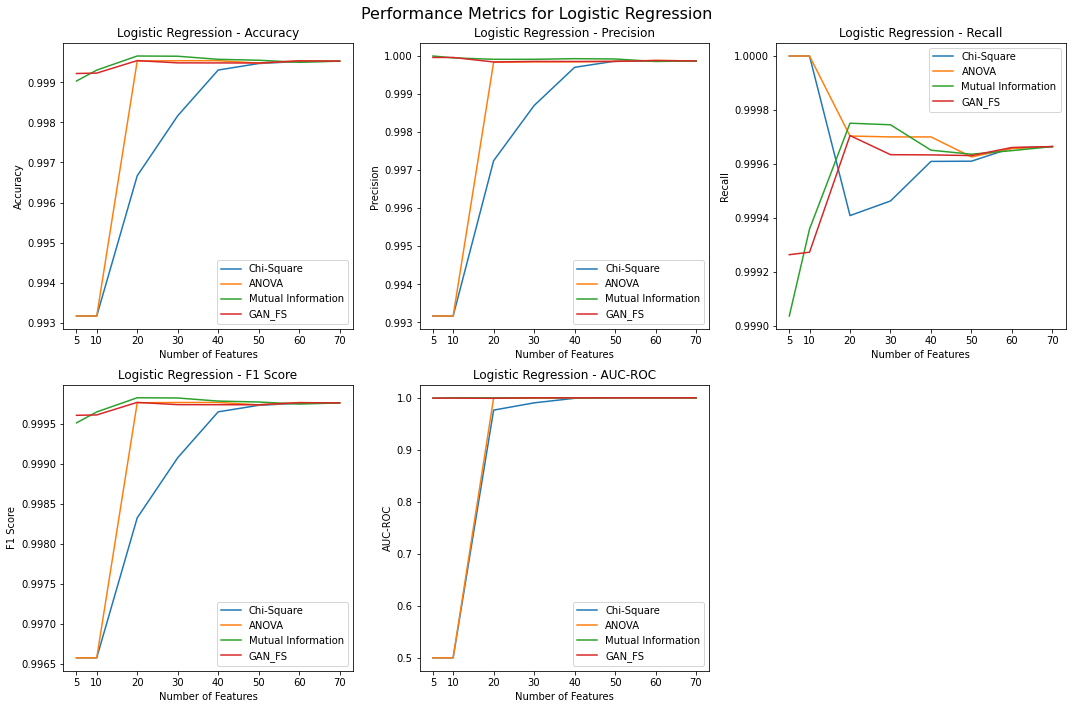

  Generating plot for Random Forest...
  Displaying plot for Random Forest...


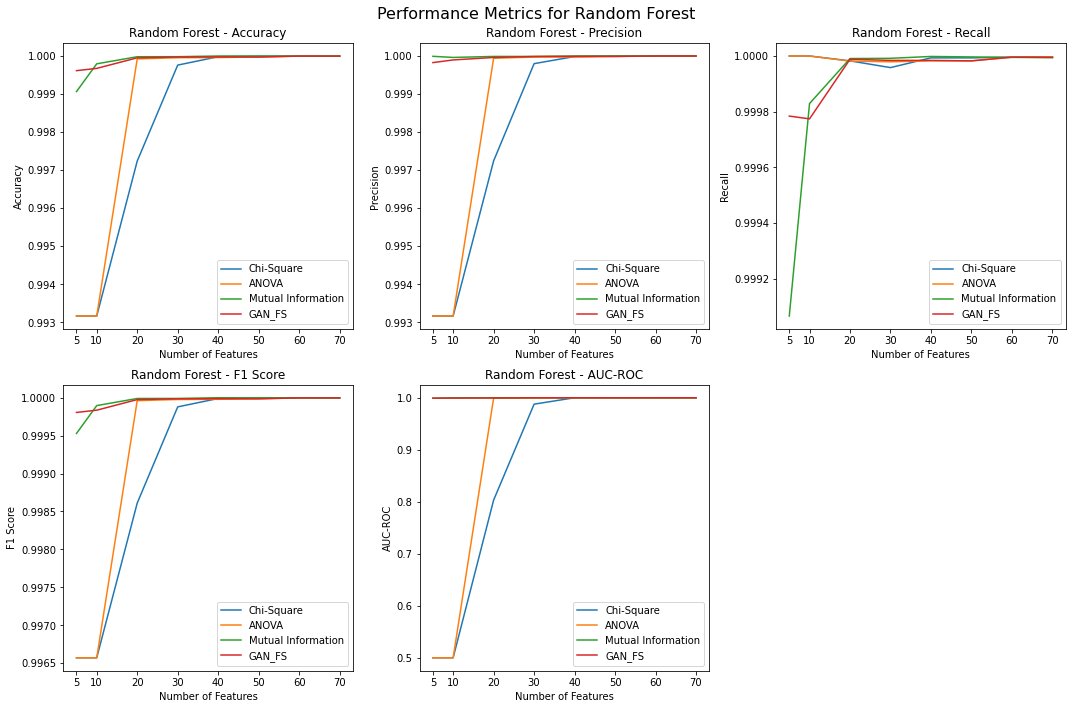

Creating training time comparison plot...
Displaying training time comparison plot...


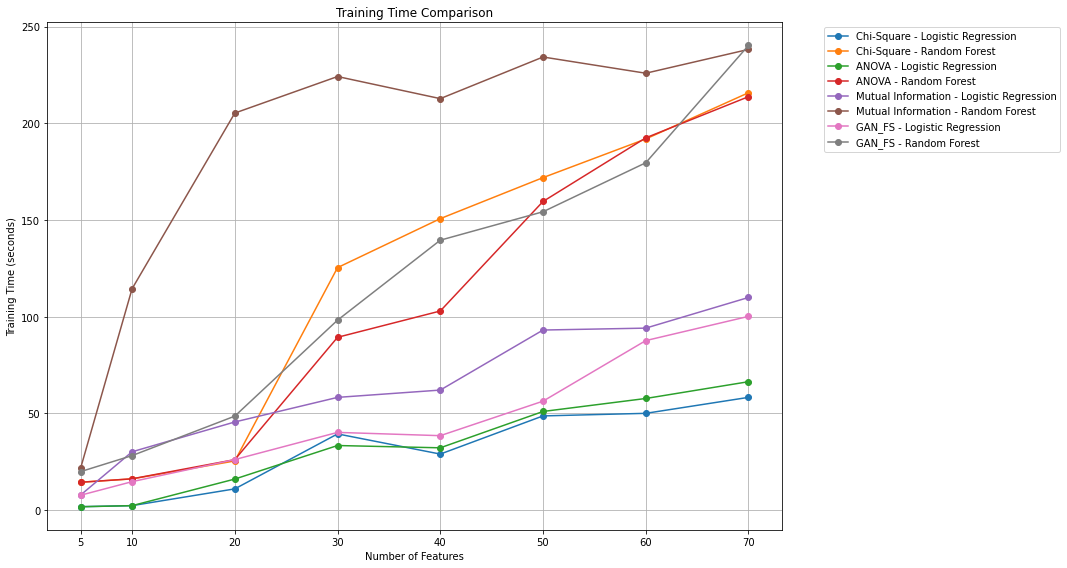

Creating model-specific training time plots...
  Displaying training time plot for Logistic Regression...


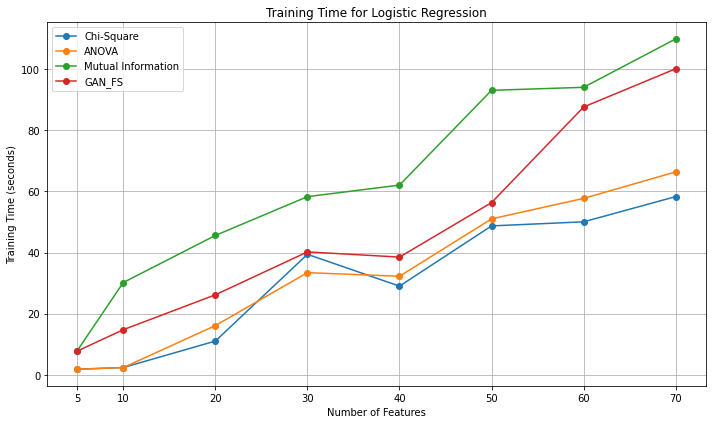

  Displaying training time plot for Random Forest...


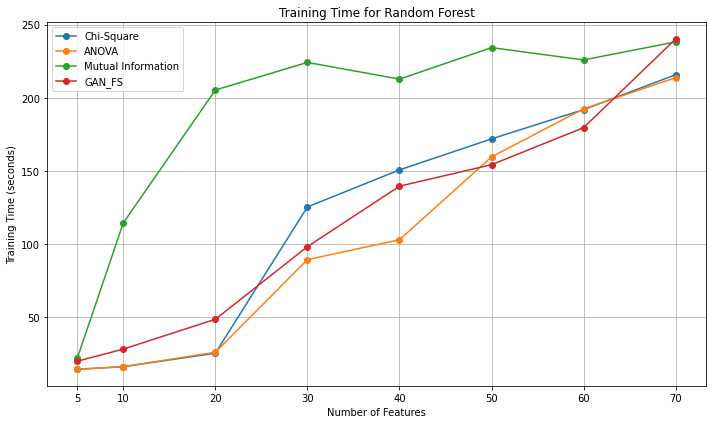

Experiment completed successfully!
{'Accuracy': {'Chi-Square': {'Logistic Regression': [0.9931670109645638, 0.9931670109645638, 0.9966670970390381, 0.998165123947243, 0.9993072660098522, 0.9994694832883098, 0.9995216245563854, 0.9995282456697918], 'Random Forest': [0.9931670109645638, 0.9931670109645638, 0.9972365127919911, 0.9997583293606653, 0.9999784813814291, 0.999991723608242, 0.9999950341649452, 0.999995861804121]}, 'ANOVA': {'Logistic Regression': [0.9931670109645638, 0.9931670109645638, 0.9995323838656709, 0.9995398326182531, 0.9995406602574289, 0.9994802425975952, 0.9995356944223741, 0.9995274180306161], 'Random Forest': [0.9931670109645638, 0.9931670109645638, 0.9999213742782986, 0.9999519969278033, 0.9999569627628582, 0.9999718602680226, 0.9999950341649452, 0.999995861804121]}, 'Mutual Information': {'Logistic Regression': [0.9990333174426611, 0.9993047830923248, 0.9996573573812172, 0.9996515639069866, 0.9995745934636369, 0.9995514195667143, 0.9995001059378145, 0.99952907330

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import time

print("Starting DDoS detection feature selection experiment...")
X_train = ddos_df_train.drop('Label', axis=1)
y_train = ddos_df_train['Label']
X_test = ddos_df_test.drop('Label', axis=1)
y_test = ddos_df_test['Label']
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

original_X_train_feature_names = X_train.columns.tolist()
print(f"Captured {len(original_X_train_feature_names)} training original feature names.")
original_X_test_feature_names = X_test.columns.tolist()
print(f"Captured {len(original_X_test_feature_names)} testing original feature names.")

# Standardize features
print("Standardizing features...")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Feature standardization complete")

print("Defining top features based on sensitivity ranking from GANFS Algorithm...")
# Define top features (Sensitivity Ranking) from GANFS Algorithm
top_features_sensitivity = sorted_feature_names

print(f"Sensitivity-ranked features: {len(top_features_sensitivity)} features")
print("First 5 features:", top_features_sensitivity[:5])
print("Last 5 features:", top_features_sensitivity[-5:])

# Combine individual and pairwise features into a new feature set
print("Creating GAN feature set...")
GAN_features = list(top_features_sensitivity)
print(f"GAN feature set created with {len(GAN_features)} features")

# Initialize models
print("Initializing machine learning models...")
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier()
}
print(f"Initialized {len(models)} models: {', '.join(models.keys())}")

# Initialize feature selection techniques
def get_best_features_selector(method, k_features):
    if method == 'Chi-Square':
        return SelectKBest(score_func=chi2, k=k_features)
    elif method == 'ANOVA':
        return SelectKBest(score_func=f_classif, k=k_features)
    elif method == 'Mutual Information':
        return SelectKBest(score_func=mutual_info_classif, k=k_features)

# Initialize results structure
results = {
    metric: {
        method: {
            model_name: [] for model_name in models.keys()
        } for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']
    } for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
}

# Initialize training times structure
training_times = {
    method: {
        model_name: [] for model_name in models.keys()
    } for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']
}

# Apply feature selection once with max features
max_features = 71
fs_outputs = {}
for fs_method in ['Chi-Square', 'ANOVA', 'Mutual Information']:
    print(f"Applying {fs_method} feature selection with {max_features} features...")
    fs = get_best_features_selector(fs_method, max_features)
    fs.fit(X_train, y_train)
    fs_outputs[fs_method] = fs

print("Feature selection outputs stored for Chi-Square, ANOVA, and Mutual Information.")

# Iterate over number of features to select
feature_counts = [5] + list(range(10, 71, 10))
print(f"Starting evaluation with feature counts: {list(feature_counts)}")

for k in feature_counts:
    print(f"\nProcessing with {k} features...")
    
    # For traditional feature selection methods
    for fs_method in ['Chi-Square', 'ANOVA', 'Mutual Information']:
        print(f"  Using top {k} features from {fs_method}...")
        
        # Get the indices of the top k features
        top_k_indices = fs_outputs[fs_method].scores_.argsort()[-k:][::-1]
        
        # Select the top k features
        X_train_fs = X_train[:, top_k_indices]
        X_test_fs = X_test[:, top_k_indices]
        
        for model_name, model in models.items():
            print(f"    Training {model_name}...")
            
            # Measure training time
            start_time = time.time()
            model.fit(X_train_fs, y_train)
            end_time = time.time()
            training_time = end_time - start_time
            
            # Store the training time
            training_times[fs_method][model_name].append(training_time)
            print(f"    {model_name} training completed in {training_time:.4f} seconds")
            
            y_pred = model.predict(X_test_fs)
            y_prob = model.predict_proba(X_test_fs)[:, 1]

            # Store results directly for this model
            results['Accuracy'][fs_method][model_name].append(accuracy_score(y_test, y_pred))
            results['Precision'][fs_method][model_name].append(precision_score(y_test, y_pred))
            results['Recall'][fs_method][model_name].append(recall_score(y_test, y_pred))
            results['F1 Score'][fs_method][model_name].append(f1_score(y_test, y_pred))
            results['AUC-ROC'][fs_method][model_name].append(roc_auc_score(y_test, y_prob))
            print(f"    {model_name} evaluation complete")
    
    # For GAN feature set
    print(f"  Applying GAN feature selection...")
    X_train_GAN = X_train[:, [original_X_train_feature_names.index(f) for f in GAN_features[:k]]]
    X_test_GAN = X_test[:, [original_X_test_feature_names.index(f) for f in GAN_features[:k]]]

    for model_name, model in models.items():
        print(f"    Training {model_name} with GAN features...")
        
        # Measure training time
        start_time = time.time()
        model.fit(X_train_GAN, y_train)
        end_time = time.time()
        training_time = end_time - start_time
        
        # Store the training time
        training_times['GAN_FS'][model_name].append(training_time)
        print(f"    {model_name} training completed in {training_time:.4f} seconds")
        
        y_pred = model.predict(X_test_GAN)
        y_prob = model.predict_proba(X_test_GAN)[:, 1]

        # Store results directly for this model
        results['Accuracy']['GAN_FS'][model_name].append(accuracy_score(y_test, y_pred))
        results['Precision']['GAN_FS'][model_name].append(precision_score(y_test, y_pred))
        results['Recall']['GAN_FS'][model_name].append(recall_score(y_test, y_pred))
        results['F1 Score']['GAN_FS'][model_name].append(f1_score(y_test, y_pred))
        results['AUC-ROC']['GAN_FS'][model_name].append(roc_auc_score(y_test, y_prob))
        print(f"    {model_name} evaluation complete")
    
    print(f"Completed evaluation with {k} features")

print("All feature selection evaluations complete. Generating plots...")

# Plotting the performance results
print("Creating overall performance comparison plot...")
plt.figure(figsize=(20, 15))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

for idx, metric in enumerate(metrics, 1):
    plt.subplot(len(metrics), 1, idx)
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        for model_name in models.keys():
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=f"{method} - {model_name}"
            )
    
    plt.title(metric)
    plt.xlabel('Number of Features')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(feature_counts)
    plt.grid(True)

plt.tight_layout()
print("Displaying overall performance comparison plot...")
plt.show()

# One figure per model for performance metrics
print("Creating individual model performance plots...")
for model_name in models.keys():
    print(f"  Generating plot for {model_name}...")
    plt.figure(figsize=(15, 10))
    
    for idx, metric in enumerate(metrics, 1):
        plt.subplot(2, 3, idx)
        
        for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=method
            )
        
        plt.title(f"{model_name} - {metric}")
        plt.xlabel('Number of Features')
        plt.ylabel(metric)
        plt.legend()
        plt.xticks(feature_counts)
    
    plt.tight_layout()
    plt.suptitle(f"Performance Metrics for {model_name}", fontsize=16)
    plt.subplots_adjust(top=0.93)
    print(f"  Displaying plot for {model_name}...")
    plt.show()

# Add plot for training times - overall comparison
print("Creating training time comparison plot...")
plt.figure(figsize=(15, 8))

for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
    for model_name in models.keys():
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=f"{method} - {model_name}",
            marker='o'
        )

plt.title("Training Time Comparison")
plt.xlabel('Number of Features')
plt.ylabel('Training Time (seconds)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(feature_counts)
plt.grid(True)
plt.tight_layout()
print("Displaying training time comparison plot...")
plt.show()

# Plot training time for each model separately
print("Creating model-specific training time plots...")
for model_name in models.keys():
    plt.figure(figsize=(10, 6))
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=method,
            marker='o'
        )
    
    plt.title(f"Training Time for {model_name}")
    plt.xlabel('Number of Features')
    plt.ylabel('Training Time (seconds)')
    plt.legend()
    plt.xticks(feature_counts)
    plt.grid(True)
    plt.tight_layout()
    print(f"  Displaying training time plot for {model_name}...")
    plt.show()

print("Experiment completed successfully!")
print(results)

Starting evaluation with feature counts: [1, 2, 3, 4, 5, 10, 20]

Processing with 1 features...
  Using top 1 features from Chi-Square...
    Training Logistic Regression...
    Logistic Regression training completed in 1.4479 seconds
    Logistic Regression evaluation complete
    Training Random Forest...
    Random Forest training completed in 12.9600 seconds
    Random Forest evaluation complete
  Using top 1 features from ANOVA...
    Training Logistic Regression...
    Logistic Regression training completed in 1.4213 seconds
    Logistic Regression evaluation complete
    Training Random Forest...
    Random Forest training completed in 12.8927 seconds
    Random Forest evaluation complete
  Using top 1 features from Mutual Information...
    Training Logistic Regression...
    Logistic Regression training completed in 2.9852 seconds
    Logistic Regression evaluation complete
    Training Random Forest...
    Random Forest training completed in 15.5853 seconds
    Random Forest 

ValueError: x and y must have same first dimension, but have shapes (7,) and (15,)

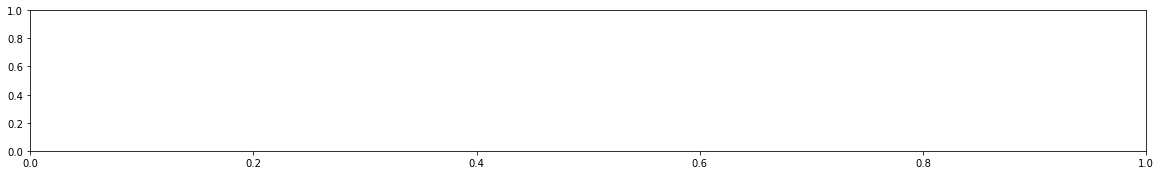

In [30]:
del results, training_times
# Initialize results structure
results = {
    metric: {
        method: {
            model_name: [] for model_name in models.keys()
        } for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']
    } for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
}

# Initialize training times structure
training_times = {
    method: {
        model_name: [] for model_name in models.keys()
    } for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']
}


# Iterate over number of features to select
feature_counts = [1, 2, 3, 4, 5] + list(range(10, 21, 10))
print(f"Starting evaluation with feature counts: {list(feature_counts)}")

for k in feature_counts:
    print(f"\nProcessing with {k} features...")
    
    # For traditional feature selection methods
    for fs_method in ['Chi-Square', 'ANOVA', 'Mutual Information']:
        print(f"  Using top {k} features from {fs_method}...")
        
        # Get the indices of the top k features
        top_k_indices = fs_outputs[fs_method].scores_.argsort()[-k:][::-1]
        
        # Select the top k features
        X_train_fs = X_train[:, top_k_indices]
        X_test_fs = X_test[:, top_k_indices]
        
        for model_name, model in models.items():
            print(f"    Training {model_name}...")
            
            # Measure training time
            start_time = time.time()
            model.fit(X_train_fs, y_train)
            end_time = time.time()
            training_time = end_time - start_time
            
            # Store the training time
            training_times[fs_method][model_name].append(training_time)
            print(f"    {model_name} training completed in {training_time:.4f} seconds")
            
            y_pred = model.predict(X_test_fs)
            y_prob = model.predict_proba(X_test_fs)[:, 1]

            # Store results directly for this model
            results['Accuracy'][fs_method][model_name].append(accuracy_score(y_test, y_pred))
            results['Precision'][fs_method][model_name].append(precision_score(y_test, y_pred))
            results['Recall'][fs_method][model_name].append(recall_score(y_test, y_pred))
            results['F1 Score'][fs_method][model_name].append(f1_score(y_test, y_pred))
            results['AUC-ROC'][fs_method][model_name].append(roc_auc_score(y_test, y_prob))
            print(f"    {model_name} evaluation complete")
    
    # For GAN feature set
    print(f"  Applying GAN feature selection...")
    X_train_GAN = X_train[:, [original_X_train_feature_names.index(f) for f in GAN_features[:k]]]
    X_test_GAN = X_test[:, [original_X_test_feature_names.index(f) for f in GAN_features[:k]]]

    for model_name, model in models.items():
        print(f"    Training {model_name} with GAN features...")
        
        # Measure training time
        start_time = time.time()
        model.fit(X_train_GAN, y_train)
        end_time = time.time()
        training_time = end_time - start_time
        
        # Store the training time
        training_times['GAN_FS'][model_name].append(training_time)
        print(f"    {model_name} training completed in {training_time:.4f} seconds")
        
        y_pred = model.predict(X_test_GAN)
        y_prob = model.predict_proba(X_test_GAN)[:, 1]

        # Store results directly for this model
        results['Accuracy']['GAN_FS'][model_name].append(accuracy_score(y_test, y_pred))
        results['Precision']['GAN_FS'][model_name].append(precision_score(y_test, y_pred))
        results['Recall']['GAN_FS'][model_name].append(recall_score(y_test, y_pred))
        results['F1 Score']['GAN_FS'][model_name].append(f1_score(y_test, y_pred))
        results['AUC-ROC']['GAN_FS'][model_name].append(roc_auc_score(y_test, y_prob))
        print(f"    {model_name} evaluation complete")
    
    print(f"Completed evaluation with {k} features")

print("All feature selection evaluations complete. Generating plots...")

# Plotting the performance results
print("Creating overall performance comparison plot...")
plt.figure(figsize=(20, 15))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

for idx, metric in enumerate(metrics, 1):
    plt.subplot(len(metrics), 1, idx)
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        for model_name in models.keys():
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=f"{method} - {model_name}"
            )
    
    plt.title(metric)
    plt.xlabel('Number of Features')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(feature_counts)
    plt.grid(True)

plt.tight_layout()
print("Displaying overall performance comparison plot...")
plt.show()

# One figure per model for performance metrics
print("Creating individual model performance plots...")
for model_name in models.keys():
    print(f"  Generating plot for {model_name}...")
    plt.figure(figsize=(15, 10))
    
    for idx, metric in enumerate(metrics, 1):
        plt.subplot(2, 3, idx)
        
        for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=method
            )
        
        plt.title(f"{model_name} - {metric}")
        plt.xlabel('Number of Features')
        plt.ylabel(metric)
        plt.legend()
        plt.xticks(feature_counts)
    
    plt.tight_layout()
    plt.suptitle(f"Performance Metrics for {model_name}", fontsize=16)
    plt.subplots_adjust(top=0.93)
    print(f"  Displaying plot for {model_name}...")
    plt.show()

# Add plot for training times - overall comparison
print("Creating training time comparison plot...")
plt.figure(figsize=(15, 8))

for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
    for model_name in models.keys():
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=f"{method} - {model_name}",
            marker='o'
        )

plt.title("Training Time Comparison")
plt.xlabel('Number of Features')
plt.ylabel('Training Time (seconds)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(feature_counts)
plt.grid(True)
plt.tight_layout()
print("Displaying training time comparison plot...")
plt.show()

# Plot training time for each model separately
print("Creating model-specific training time plots...")
for model_name in models.keys():
    plt.figure(figsize=(10, 6))
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=method,
            marker='o'
        )
    
    plt.title(f"Training Time for {model_name}")
    plt.xlabel('Number of Features')
    plt.ylabel('Training Time (seconds)')
    plt.legend()
    plt.xticks(feature_counts)
    plt.grid(True)
    plt.tight_layout()
    print(f"  Displaying training time plot for {model_name}...")
    plt.show()

print("Experiment completed successfully!")
print(results)

Creating overall performance comparison plot...
Displaying overall performance comparison plot...


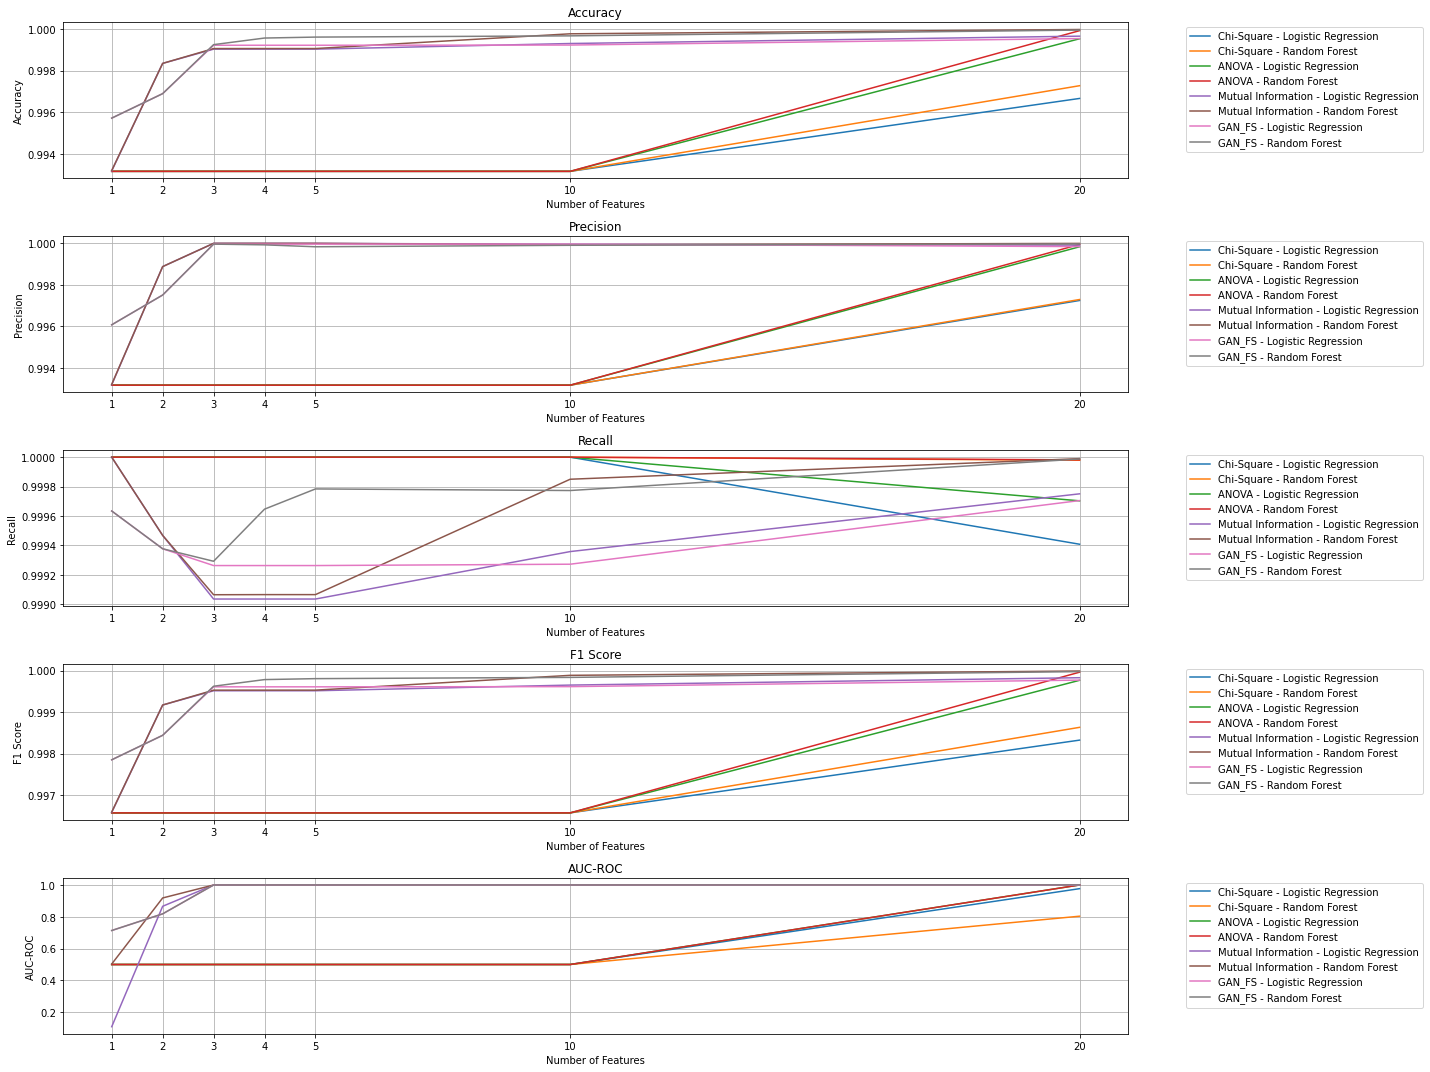

Creating individual model performance plots...
  Generating plot for Logistic Regression...
  Displaying plot for Logistic Regression...


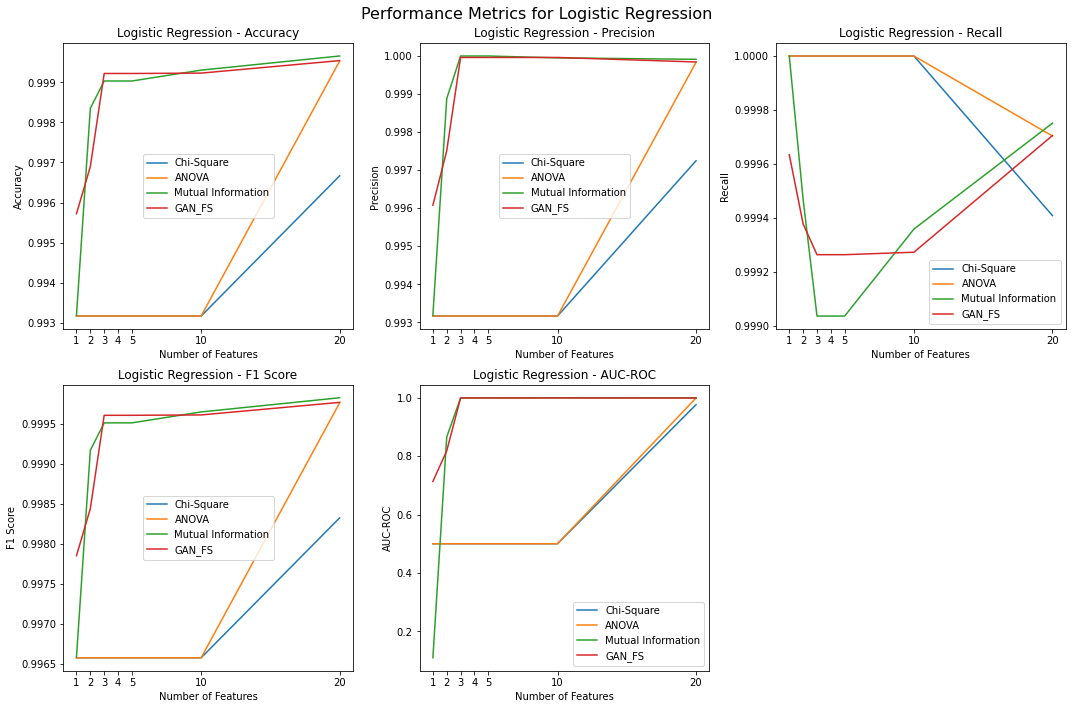

  Generating plot for Random Forest...
  Displaying plot for Random Forest...


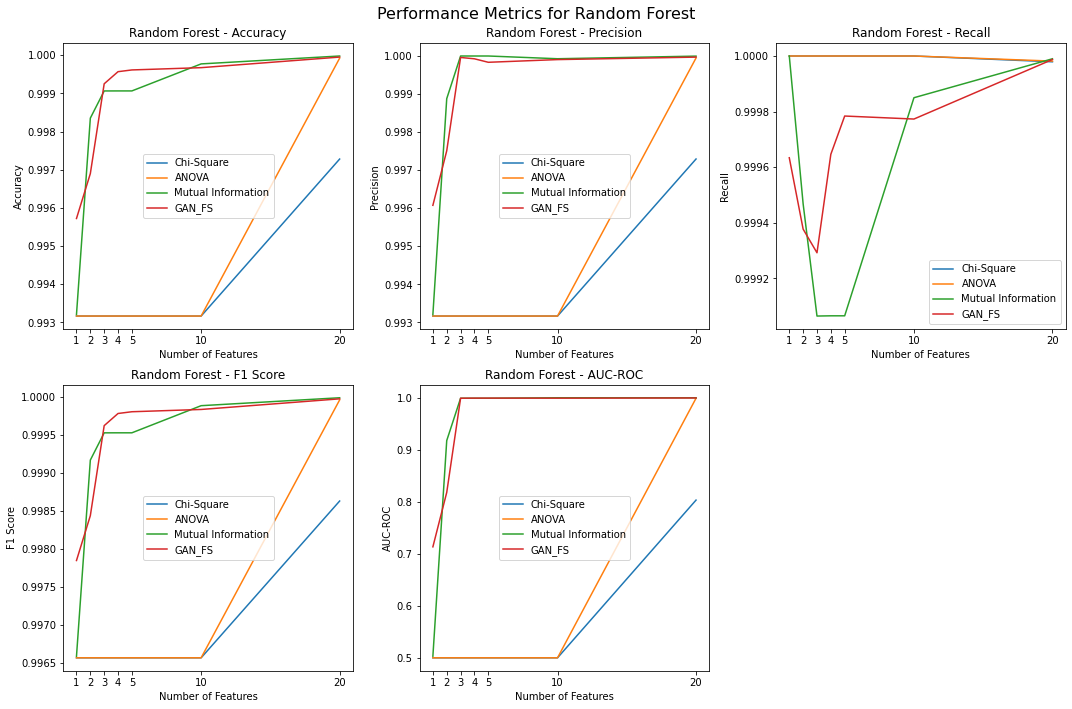

Creating training time comparison plot...


ValueError: x and y must have same first dimension, but have shapes (7,) and (15,)

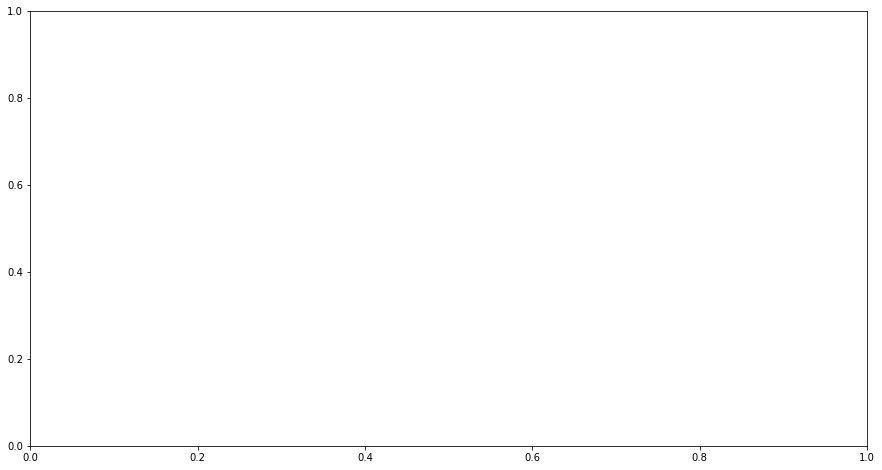

In [43]:
# Plotting the performance results
print("Creating overall performance comparison plot...")
plt.figure(figsize=(20, 15))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

for idx, metric in enumerate(metrics, 1):
    plt.subplot(len(metrics), 1, idx)
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        for model_name in models.keys():
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=f"{method} - {model_name}"
            )
    
    plt.title(metric)
    plt.xlabel('Number of Features')
    plt.ylabel(metric)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(feature_counts)
    plt.grid(True)

plt.tight_layout()
print("Displaying overall performance comparison plot...")
plt.show()

# One figure per model for performance metrics
print("Creating individual model performance plots...")
for model_name in models.keys():
    print(f"  Generating plot for {model_name}...")
    plt.figure(figsize=(15, 10))
    
    for idx, metric in enumerate(metrics, 1):
        plt.subplot(2, 3, idx)
        
        for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
            plt.plot(
                feature_counts, 
                results[metric][method][model_name], 
                label=method
            )
        
        plt.title(f"{model_name} - {metric}")
        plt.xlabel('Number of Features')
        plt.ylabel(metric)
        plt.legend()
        plt.xticks(feature_counts)
    
    plt.tight_layout()
    plt.suptitle(f"Performance Metrics for {model_name}", fontsize=16)
    plt.subplots_adjust(top=0.93)
    print(f"  Displaying plot for {model_name}...")
    plt.show()

# Add plot for training times - overall comparison
print("Creating training time comparison plot...")
plt.figure(figsize=(15, 8))

for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
    for model_name in models.keys():
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=f"{method} - {model_name}",
            marker='o'
        )

plt.title("Training Time Comparison")
plt.xlabel('Number of Features')
plt.ylabel('Training Time (seconds)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(feature_counts)
plt.grid(True)
plt.tight_layout()
print("Displaying training time comparison plot...")
plt.show()

# Plot training time for each model separately
print("Creating model-specific training time plots...")
for model_name in models.keys():
    plt.figure(figsize=(10, 6))
    
    for method in ['Chi-Square', 'ANOVA', 'Mutual Information', 'GAN_FS']:
        plt.plot(
            feature_counts, 
            training_times[method][model_name], 
            label=method,
            marker='o'
        )
    
    plt.title(f"Training Time for {model_name}")
    plt.xlabel('Number of Features')
    plt.ylabel('Training Time (seconds)')
    plt.legend()
    plt.xticks(feature_counts)
    plt.grid(True)
    plt.tight_layout()
    print(f"  Displaying training time plot for {model_name}...")
    plt.show()

print("Experiment completed successfully!")
print(results)